Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")



## Steps 1-5: Cleaning/prepping data

In [3]:
def preprocess_movies_data(movie_metadata):
    # Keeping columns that are needed
    cols_to_keep = ['color', 'num_critic_for_reviews', 'duration', 'gross', 
                    'num_voted_users', 'country', 'language', 'content_rating', 
                    'budget', 'title_year', 'aspect_ratio', 'imdb_score']
    movies_data = movie_metadata[cols_to_keep].copy()

    # Recode country to USA vs Other
    movies_data['country'] = movies_data['country'].apply(
        lambda x: 'USA' if x == 'USA' else 'Other'
    )

    # Recode language to English vs Other
    movies_data['language'] = movies_data['language'].apply(
        lambda x: 'English' if x == 'English' else 'Other'
    )

    # Recode content_rating to standard ratings vs Other
    valid_ratings = ['G', 'PG', 'PG-13', 'R']
    movies_data['content_rating'] = movies_data['content_rating'].apply(lambda x: x if x in valid_ratings else 'Other')

    # Convert categorical variables
    label_encoder = LabelEncoder()
    for col in ['color', 'country', 'language', 'content_rating']:
        movies_data[col] = label_encoder.fit_transform(movies_data[col])

    # Drop rows with missing values
    movies_data = movies_data.dropna()

    return movies_data

cleaned_movies_data = preprocess_movies_data(movie_metadata)
cleaned_movies_data

,color,num_critic_for_reviews,duration,gross,num_voted_users,country,language,content_rating,budget,title_year,aspect_ratio,imdb_score
0,1,723.0,178.0,760505847.0,886204,1,0,3,237000000.0,2009.0,1.78,7.9
1,1,302.0,169.0,309404152.0,471220,1,0,3,300000000.0,2007.0,2.35,7.1
2,1,602.0,148.0,200074175.0,275868,0,0,3,245000000.0,2015.0,2.35,6.8
3,1,813.0,164.0,448130642.0,1144337,1,0,3,250000000.0,2012.0,2.35,8.5
5,1,462.0,132.0,73058679.0,212204,1,0,3,263700000.0,2012.0,2.35,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...
5027,1,64.0,90.0,673780.0,4555,0,1,1,10000.0,2000.0,1.85,7.5
5029,1,78.0,111.0,94596.0,6318,0,1,1,1000000.0,1997.0,1.85,7.4
5033,1,143.0,77.0,424760.0,72639,1,0,3,7000.0,2004.0,1.85,7.0
5035,1,56.0,81.0,2040920.0,52055,1,1,4,7000.0,1992.0,1.37,6.9


In [4]:
# Calculating variance
np.var(cleaned_movies_data['gross'])

np.float64(4919924337646581.0)

<Axes: ylabel='gross'>

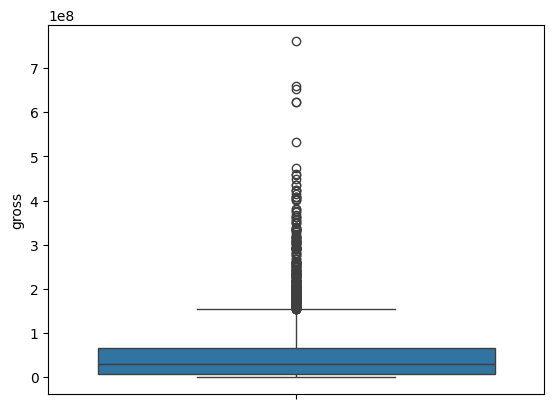

In [5]:
# Boxplot of target variable
sns.boxplot(cleaned_movies_data['gross'])

We can see that our variable is highly skewed. We can correct for this issue by taking the log of our target variable and dropping the highest outliers.

In [6]:
# Dropping our highest outliers
cleaned_movies_data = cleaned_movies_data.drop(cleaned_movies_data[cleaned_movies_data['gross'] > 5e8].index)

<Axes: xlabel='gross', ylabel='Count'>

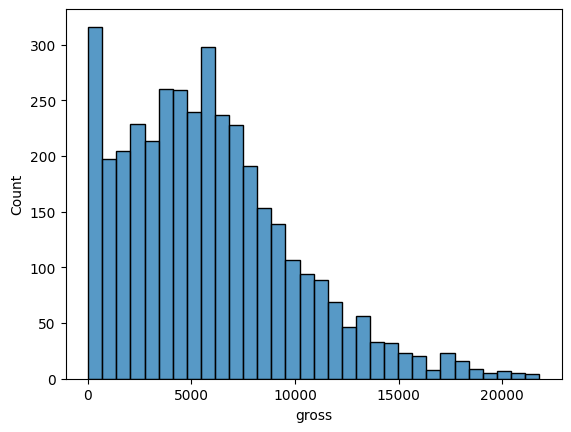

In [7]:
target = np.sqrt(cleaned_movies_data['gross'])
sns.histplot(target)

## Steps 6-13: Building out model

In [8]:
# Train/tune/test split
X = cleaned_movies_data.drop(columns='gross')
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=13)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50, random_state=72)

# Creating k-fold object for validiation
kf =RepeatedKFold(n_splits=10,n_repeats =5, random_state=42)

# Selecting scoring metrics
scoring = ['neg_mean_squared_error','r2','neg_mean_absolute_error']
# Choosing min samples leaf as our parameter to avoid overfitting
param={"min_samples_leaf" : [2,4,6,8,10]}

# Building regression tree object
reg=DecisionTreeRegressor(random_state=30)

#Setting up gridsearch, executing on training data
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='neg_mean_squared_error')
model = search.fit(X_train, y_train)

In [9]:
# Pulling metrics from model
mean_sq_err = np.sqrt(abs(model.cv_results_['mean_test_neg_mean_squared_error']))
r2= model.cv_results_['mean_test_r2']
mae= abs(model.cv_results_['mean_test_neg_mean_absolute_error'])

#Parameter(min leaf)
min_leaf= np.unique(model.cv_results_['param_min_samples_leaf']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(min_leaf, mean_sq_err, r2,mae)),
               columns =['min leaf','rmse','r2','mae'])

final_model

,min leaf,rmse,r2,mae
0,2,2855.832481,0.510537,2115.724944
1,4,2656.952693,0.576989,1970.282518
2,6,2558.567784,0.607949,1896.379522
3,8,2481.092022,0.631362,1844.607333
4,10,2456.099059,0.638750,1828.931645


In [10]:
# Creating model object
best = model.best_estimator_

## Steps 14-16: Evauluating model performance

In [11]:
# Finding variable importance
varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                        importance
num_voted_users           0.594519
budget                    0.197570
content_rating            0.061932
title_year                0.038755
country                   0.033151
num_critic_for_reviews    0.029450
imdb_score                0.026894
duration                  0.015286
aspect_ratio              0.001450
language                  0.000993
color                     0.000000


In [12]:
# Predicting on the tune data
y_pred_tune = best.predict(X_tune)
print(y_pred_tune[:10])

[ 2132.77906632  2367.92354012 11546.66271593  7955.25341533
  3296.03778606  7039.85715088  6670.0429699   1118.92268008
   813.4452248   5776.20087009]


In [13]:
# Comparing how the model does on tune vs. test data
print("Tune score:", best.score(X_tune, y_tune))
print("Tune score:", best.score(X_train, y_train))

Tune score: 0.6026765724596248
Tune score: 0.8129173176275535


The model performs significantly better on our testing data. This may indicate that our model is over fitting to our training data and therefore not generalizing well beyond this set.

In [14]:
# Finding the 5 highest predicted movies from the tune set
top_5_indices = y_pred_tune.argsort()[-5:][::-1]

# Get the movie titles and gross values of the top 5 movies
top_5_movies = movie_metadata.loc[top_5_indices, ['movie_title', 'gross']]

# Print the top 5 movies
print(top_5_movies)

                   movie_title        gross
210                   X-Men 2   214948780.0
44       Terminator Salvation   125320003.0
298  The Emperor's New Groove    89296573.0
160                 Star Trek   257704099.0
152           Men in Black II   190418803.0


## Steps 17-20: What if?

Our model performed far better on our training data than our tune data, indicating there may be some degree of over fitting. In order to correct for this we can alter our parameters to control and block from serious over fitting and create a more generalizable model. We could also change our scoring metrics and refit the model based on a different metric to see if it performs better. More specifically, I will test if refitting using r2 score will improve our model, aiming for higher correlation rather than minimizing error. I also will use max_depth instead of min_samples_leaf to see if this improves our model.

After playing around with some metrics, I found that our model performed slightly better on our tune data when we used r2 to refit rather than neg_mean_squared_error. 

In [15]:
# Selecting scoring metrics
scoring_1 = ['neg_mean_squared_error','r2','neg_mean_absolute_error']
# Choosing min samples leaf as our parameter to avoid overfitting
param_1={"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10,15,20]}

search_1 = GridSearchCV(reg, param_1, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')
model_1 = search_1.fit(X_train, y_train)
best_1 = model_1.best_estimator_

print("Tune score:", best_1.score(X_tune, y_tune))
print("Train score:", best_1.score(X_train, y_train))

Tune score: 0.6408744040594463
Train score: 0.7571832737579759


Using max_depth rather than min_samples leaf:

In [16]:
# Selecting scoring metrics
scoring_1 = ['neg_mean_squared_error','r2','neg_mean_absolute_error']
# Choosing min samples leaf as our parameter to avoid overfitting
param_2={"max_depth":[1,2,3,4,5,6,7,8,9,10]}

search_2 = GridSearchCV(reg, param_2, scoring=scoring, n_jobs=-1, cv=kf,refit='neg_mean_squared_error')
model_2 = search_2.fit(X_train, y_train)
best_2 = model_2.best_estimator_

print("Tune score:", best_2.score(X_tune, y_tune))
print("Train score:", best_2.score(X_train, y_train))

Tune score: 0.6071887089605981
Train score: 0.7273414900767547


From this process(I didn't include all of the code) I found that using max depth actually decreased how our model performed on both the train and tune data. However, when using r2 score to refit I found that the tune score increased while the train score decreased. Since we want our model to perform well on tune/test data rather than training data, the model using r2 score to refit will be the one we consider to be the best and proceed with.

In [17]:
# Analyzing performance of new model
from sklearn.metrics import r2_score

pred_test = best_1.predict(X_test)
print("Test MSE:", np.sqrt(metrics.mean_squared_error(y_test, pred_test)))
print("Test MAE:", metrics.mean_absolute_error(y_test, pred_test))
print("R²:", r2_score(y_test, pred_test))

Test MSE: 2268.610883848986
Test MAE: 1759.2322338306592
R²: 0.6409783907912234


Our R^2 score indicated a moderate correlation between our tune data and our predictions. Our response variable is the square root of gross revenue(which is still a very large number) these error values make sense. They may seem very high but once considering the magnitude of units we are using they are indicative of no greatly concerning error.

In [18]:
print("Tune score:", best_1.score(X_tune, y_tune))
print("Test score:", best_1.score(X_test, y_test))

Tune score: 0.6408744040594463
Test score: 0.6409783907912234


Our model performs similarly on our test data as our tune data which makes sense. It undergoes the same process, previously unseen data that is being checked.

## Steps 21-22: Where did error occur, next steps

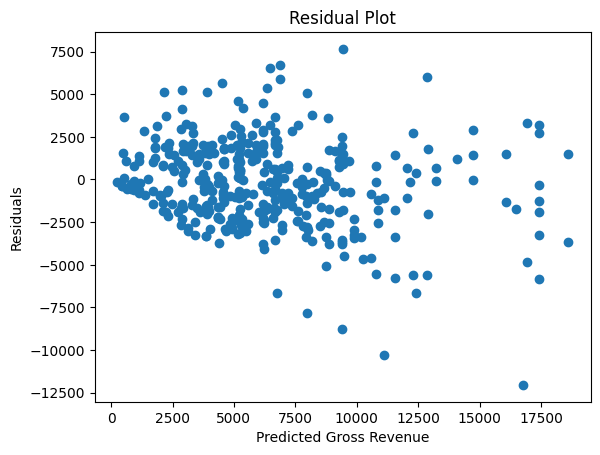

In [19]:
# Figuring out where errors happened by looking at residuals
test_res = y_tune - y_pred_tune
plt.scatter(y_pred_tune, test_res)
plt.xlabel('Predicted Gross Revenue')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

This scatterplot of residuals shows a bit of a fanning pattern. That is to say when predicted gross revenue is higher, our predictions are less accurate. Most of our residuals are centered around one, especially when our predicted revenues are closer to 0. Let's take a look at our residuals plotted against num_voted_users(our most important variable):

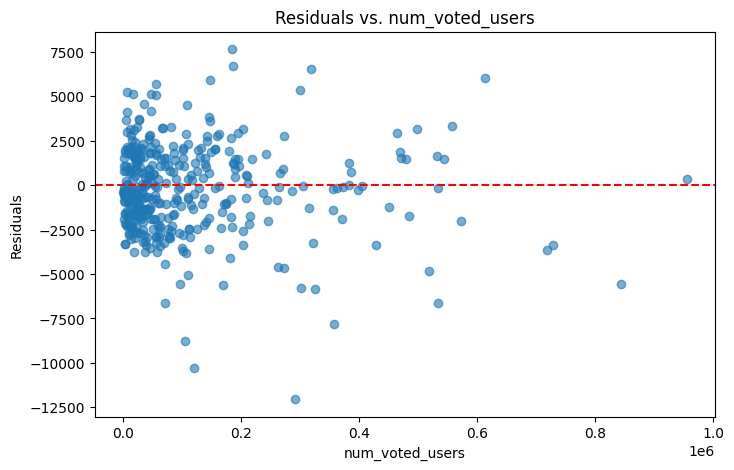

In [20]:
# Plotting residuals against our most important variable
plt.figure(figsize=(8, 5))
plt.scatter(X_tune['num_voted_users'], test_res, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("num_voted_users")
plt.ylabel("Residuals")
plt.title("Residuals vs. num_voted_users")
plt.show()

Here we do not see much of a fanning pattern. However, we can see that most of our num_voted_users are centered around 0. This means that our most important variable is highly skewed and could be the source of error. Values near 0.4*1e6 have pretty large residuals which may be causing issues. 

{'whiskers': [<matplotlib.lines.Line2D at 0xffff99d89310>,
 'caps': [<matplotlib.lines.Line2D at 0xffff99d898e0>,
 'boxes': [<matplotlib.lines.Line2D at 0xffff550fc080>],
 'medians': [<matplotlib.lines.Line2D at 0xffff99d89eb0>],
 'fliers': [<matplotlib.lines.Line2D at 0xffff99d8a1b0>],
 'means': []}

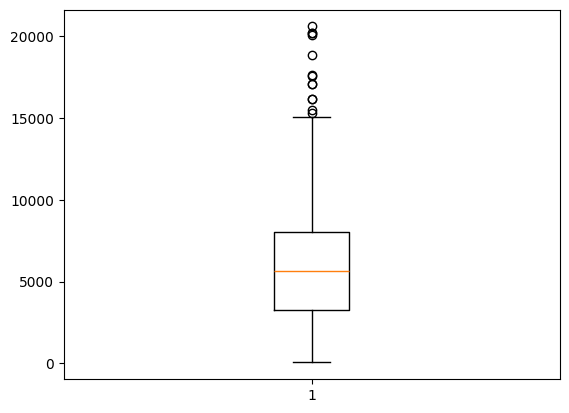

In [21]:
plt.boxplot(y_tune)

We can see there are a fair amount of outliers for our tune data. This is likely a source of error. If we remove these outliers then we may see our model perform better. Early on, we identified this as a potential issue. I didn't want to just remove outliers as I feel that these are still important data points. High grossing movies should not just be ignored. This is why we transformed our response variable, but perhaps a more severe transformation was needed. Our model is highly impacted by these outliers and we must keep this in mind when sharing our conclusions. We want to let those who are seeing the results understand that incredibly high grossing movies may not be best suited for our model.

#### Final remarks
Throughout this process, I have seen that many factors must be considered while building a decision tree model. The only real way to understand the best possible combination of features is through trial and error and analyzing the outputs of various combinations of alterations. I also have come to realize that while the tools we are learning are important, they do not mean much if you don't know what to do with the output. Calculating a very high error doesn't matter if you don't know what it practically means or how to fix it. 

I also have found that when we are working with datasets with large values and skewed data/outliers, our models can be very prone to error. We must consider how to control for this early on as it will be hard to fix once the model has been built out and tweaked. Interpreting results is also important as we must make sure our results have practical meaning.

Going forwards, this model can be used well to model movies that are aiming to produce high revenue, but it may not be best for massive blockbuster movies. The combination of our features seem to not do well at predicting these massive gross values. Therefore, if someone in Hollywood was trying to make a massive hit I would advise caution when using this model. 